In [1]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
from os import listdir
from pathlib import Path
from scipy.signal import convolve

new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
plt.rcParams.update(new_rc_params)

In [2]:
def load_spiking_data(directory, population, var_of_interest, inhib = True):
    neural_act = []
    stim_id = []
    if inhib:
        inhib_folder = 'ScaleTH/'
    else:
        inhib_folder = 'ScaleTH/'
    lst = listdir('./neural_activity/' + inhib_folder + directory + population + var_of_interest)
    sorted_files = sorted(lst, key=lambda x: int(x.split('.')[0]))
    for f in sorted_files:
        neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
        stim_id.append(Path(f).stem)
    neural_act = np.asarray(neural_act, dtype='object')
    stim_id = np.asarray(stim_id, dtype=int)
    return neural_act, stim_id

In [3]:
def compute_nb_spike_per_neuron(data, popsize):
    data = np.asarray(data, dtype=int)
    spike_per_neuron = np.zeros(popsize)
    for i in np.unique(data):
        spike_per_neuron[i] = np.sum(np.where(data == i, 1, 0))

    return spike_per_neuron

In [ ]:
def compute_spontaneous_activity(spike_times, duration):
    spontaneous_activity = np.zeros(duration)
    spike_times = np.asarray(spike_times, dtype=int)
    for i in range(duration):
        spontaneous_activity[i] = sum(spike_times==i)
    return spontaneous_activity

In [ ]:
def compute_spontaneous_activity(spike_times, duration):
    spike_times = np.asarray(spike_times, dtype=int)
    spontaneous_activity = np.bincount(spike_times, minlength=duration)
    return spontaneous_activity

In [5]:
def load_data(directory):
    torques = []
    stim_id = []
    for f in listdir(directory):
        torques.append(np.genfromtxt(directory + '/' + f, delimiter=','))
        stim_id.append(Path(f).stem)
    torques = np.asarray(torques)
    return torques, stim_id

In [6]:
def compute_amplitude(torques):
    amplitude = []
    for i in range(len(torques)):
        amplitude.append(np.sqrt(torques[i][1]**2 + torques[i][2]**2))
    return np.asarray(amplitude)

def compute_amplitude_ONOFF(amplitude, th):
    amplitude_ONOFF = np.zeros(len(amplitude))
    th_reached = np.argwhere(amplitude > th)
    amplitude_ONOFF[th_reached[0][0]:th_reached[-1][0]] += 1
    return amplitude_ONOFF

def compute_direction(direction, amplitude):
    direction_array = np.ones(len(amplitude)) * direction
    return direction_array

In [7]:
def filter_signal_hanning(signal, window_size):
    """
    Filters a signal using a Hanning window.

    Parameters:
        signal (array-like): The input signal to be filtered.
        window_size (int): The size of the Hanning window. Should be an odd number.

    Returns:
        filtered_signal (numpy.ndarray): The filtered signal.
    """
    if window_size % 2 == 0:
        raise ValueError("window_size must be an odd number to ensure proper filtering.")
    
    # Create a Hanning window
    hanning_window = np.hanning(window_size)
    
    # Normalize the window to ensure signal amplitude is preserved
    hanning_window /= hanning_window.sum()
    
    # Apply the window to the signal using convolution
    filtered_signal = convolve(signal, hanning_window, mode='same')
    
    return filtered_signal



WARNING    C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_21304\3823430018.py:11: UserWarning: genfromtxt: Empty input file: "./neural_activity/ScaleTH/0_distance_to_basis/SA2/spike_time/19.csv"
  neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
 [py.warnings]
WARNING    C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_21304\3823430018.py:11: UserWarning: genfromtxt: Empty input file: "./neural_activity/ScaleTH/0_distance_to_basis/SA2/spike_id/19.csv"
  neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
 [py.warnings]
WARNING    C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_21304\3823430018.py:11: UserWarning: genfromtxt: Empty input file: "./neural_activity/ScaleTH/0_frequency/SA2/spike_time/2.csv"
  neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_

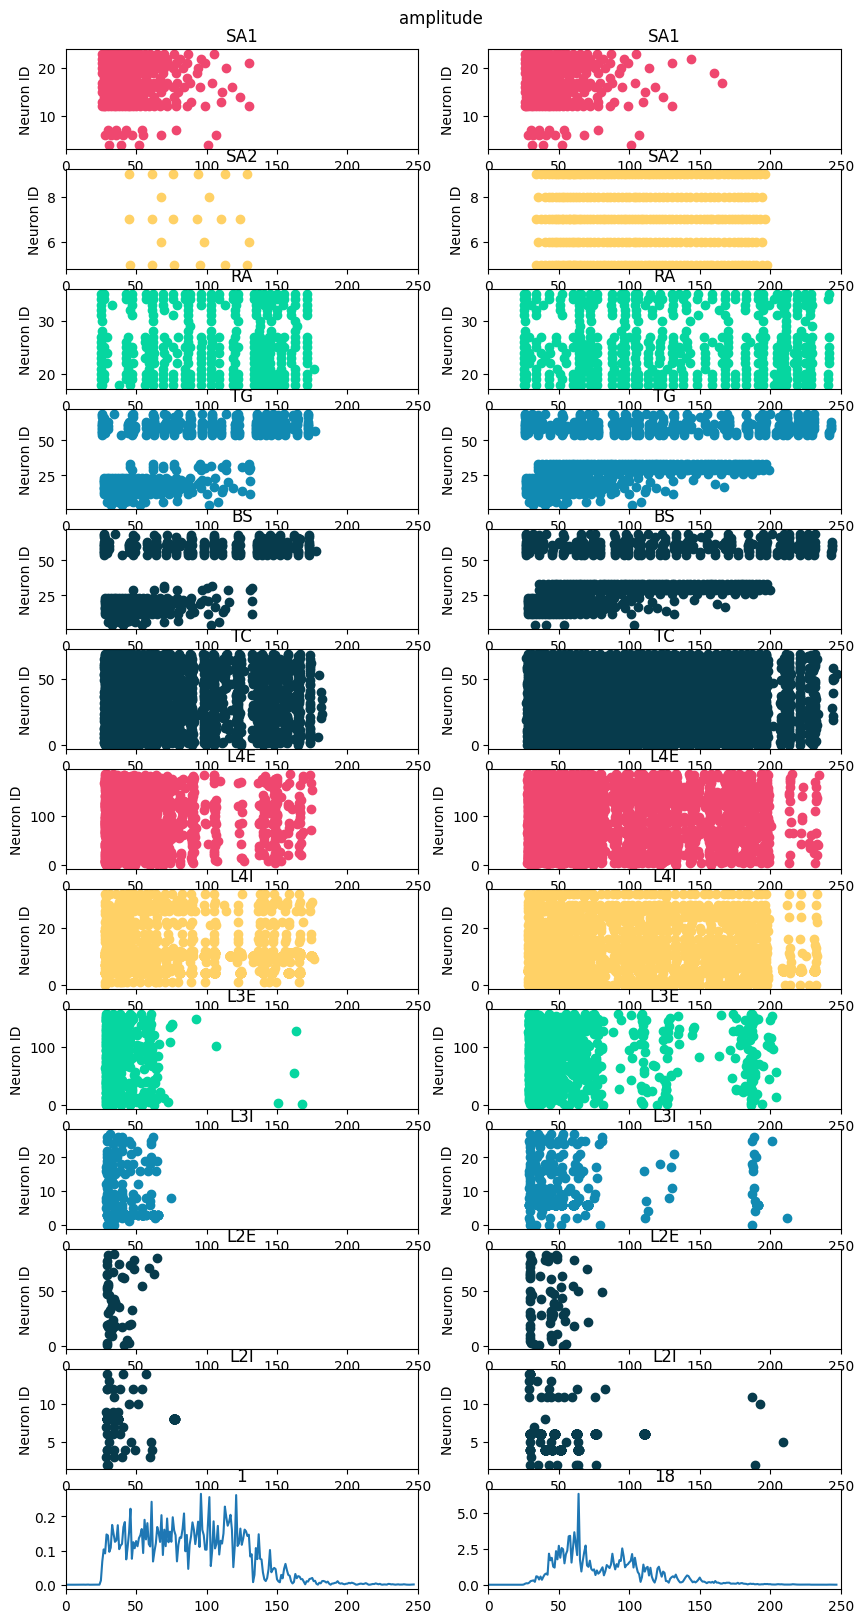

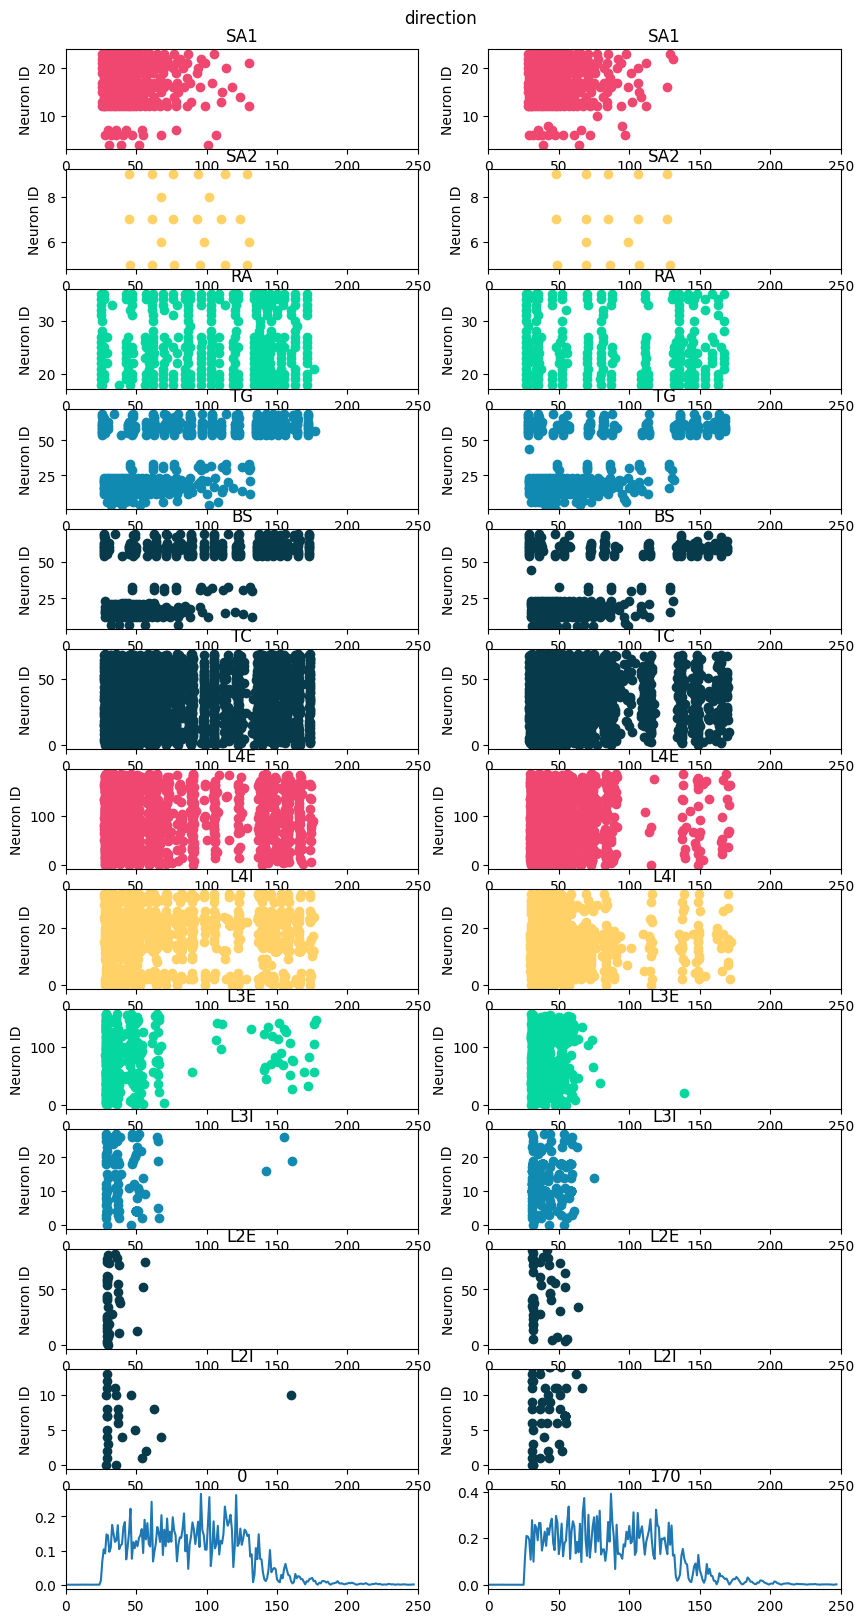

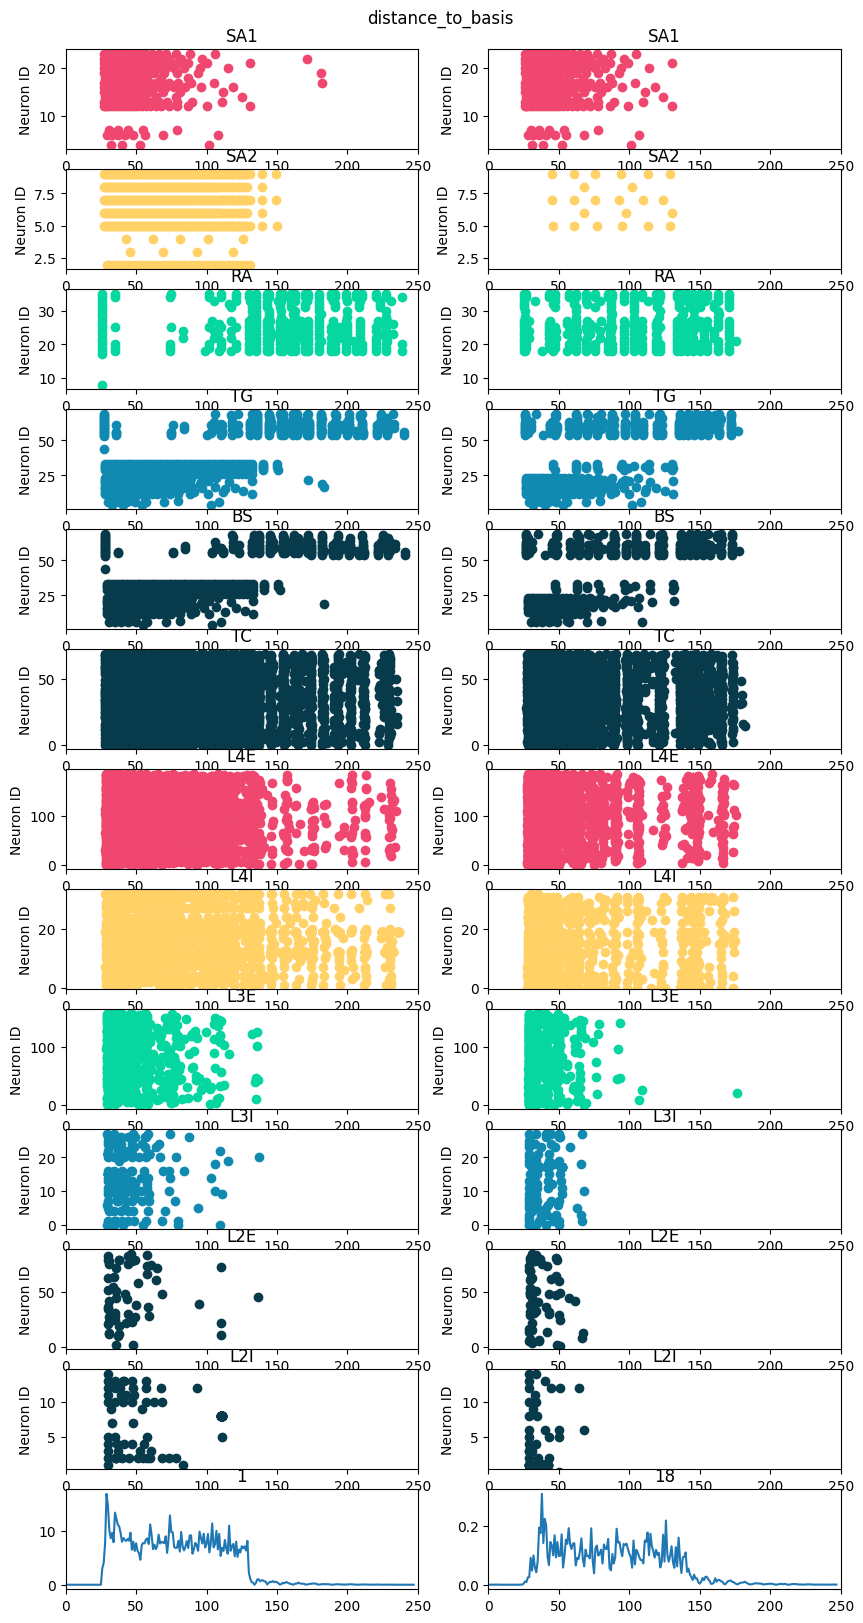

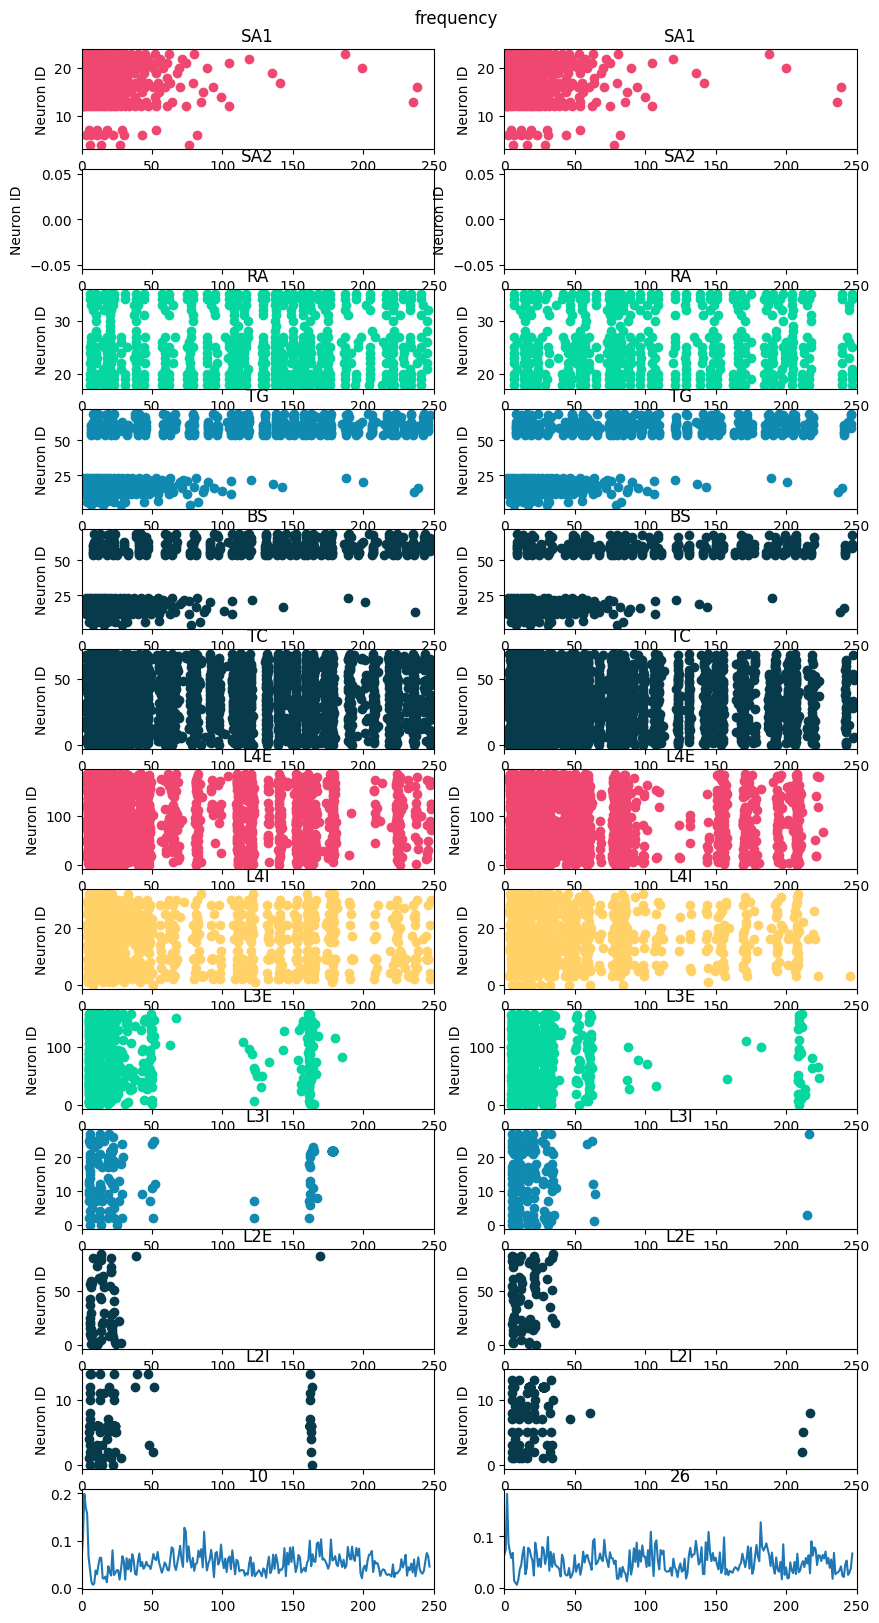

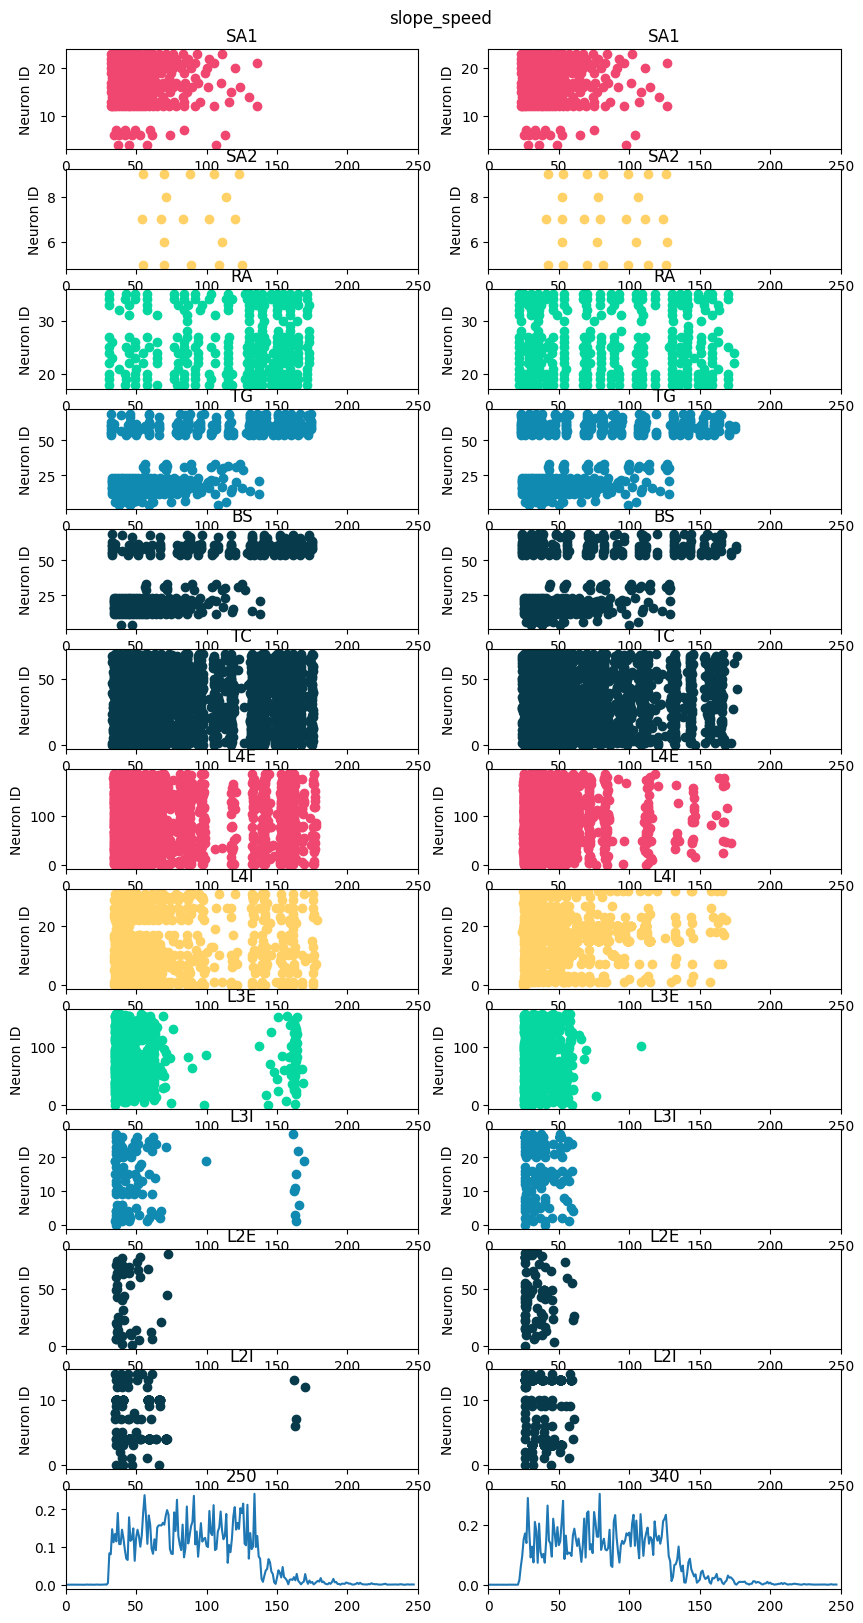

In [ ]:
stimuli = ['0_amplitude', '0_direction', '0_distance_to_basis', '0_frequency', '0_slope_speed']
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS', 'TC', 'L4E', 'L4I', 'L3E', 'L3I', 'L2E', 'L2I']
Populations_label = ['SA1', 'SA2', 'RA', 'TG', 'BS', 'TC', 'L4E', 'L4I', 'L3E', 'L3I', 'L2E', 'L2I']
Colors = ['#ef476f', '#ffd166', '#06d6a0', '#118ab2', '#073b4c', '#073b4c', '#ef476f', '#ffd166', '#06d6a0', '#118ab2', '#073b4c', '#073b4c']
idx_low = 0
idx_high = 9
for s in stimuli:
    fig, axs = plt.subplots(13, 2, figsize=(10, 20))
    fig.suptitle(s[2:], y=0.9)
    torques, stim_id = load_data('./' + s + '/Moments')

    for idx, pop in enumerate(Populations):
        sp_time, _ = load_spiking_data(s + '/', pop + '/', 'spike_time')
        sp_id, _ = load_spiking_data(s + '/', pop + '/', 'spike_id')
        axs[idx, 0].scatter(sp_time[idx_low] * 1000, sp_id[idx_low], color=Colors[idx], alpha=1)
        #rate1 = compute_spontaneous_activity(sp_time[idx_low] * 1000, 250)
        #axs[idx, 0].plot(rate1, color = 'gray')
        axs[idx, 0].set_xlim([0, 250])
        axs[idx, 0].set_title(Populations_label[idx])
        axs[idx, 0].set_xlabel('Time(s)')
        axs[idx, 0].set_ylabel('Neuron ID')
        axs[idx, 1].scatter(sp_time[idx_high] * 1000, sp_id[idx_high], color=Colors[idx], alpha=1)
        axs[idx, 1].set_ylim(axs[idx, 0].get_ylim())
        #rate2 = compute_spontaneous_activity(sp_time[idx_high] * 1000, 250)
        #axs[idx, 1].plot(rate2, color = 'gray')
        axs[idx, 1].set_xlim([0, 250])
        axs[idx, 1].set_title(Populations_label[idx])
        axs[idx, 1].set_xlabel('Time(s)')
        axs[idx, 1].set_ylabel('Neuron ID')
    axs[12, 0].plot(compute_amplitude(torques[idx_low][1:]))
    axs[12, 0].set_title(stim_id[idx_low])
    axs[12, 0].set_xlim([0, 250])
    axs[12, 1].plot(compute_amplitude(torques[idx_high][1:]))
    axs[12, 1].set_title(stim_id[idx_high])
    axs[12, 1].set_xlim([0, 250])
    plt.savefig('./Figures/Rasters/NeuronalActivityVisualisation_scatter' + s + '.svg')